# Cropping a plot with `crop_coord`

Most spatial datasets are far larger than the region you want to look at. `crop_coord` restricts a
plot to a bounding box **at draw time**: the `SpatialData` object is untouched, only the window is
rendered — and for images and labels only the window is ever rasterized, so zooming into a
gigapixel slide costs about as much as plotting a thumbnail.

This tutorial uses the Xenium `cells` dataset from `squidpy.datasets` (a 550 × 450 µm section with a
four-channel fluorescence image, cell and nucleus segmentations, transcripts and a cell table).

## Setup

In [1]:
import warnings

import matplotlib.pyplot as plt
import squidpy as sq
from matplotlib.patches import ConnectionPatch, Rectangle

import spatialdata as sd
import spatialdata_plot  # noqa: F401  # registers the .pl accessor
from spatialdata_plot import PercentileNormalize

warnings.filterwarnings("ignore")

sdata = sq.datasets.cells()
sdata

INFO     Loading existing dataset from data/spatialdata/cells.zarr                                                 


SpatialData object, with associated Zarr store: /Users/tim.treis/Documents/GitHub/spatialdata-plot-notebooks/tutorials/data/spatialdata/cells.zarr
├── Images
│     ├── 'he_aligned': DataTree[cyx] (3, 430, 540), (3, 215, 270)
│     ├── 'he_image': DataTree[cyx] (3, 423, 339), (3, 211, 169)
│     └── 'morphology_focus': DataTree[cyx] (4, 430, 540), (4, 215, 270)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (430, 540), (215, 270)
│     ├── 'nucleus_labels': DataTree[yx] (430, 540), (215, 270)
│     └── 'tissue_labels': DataTree[yx] (430, 540), (215, 270)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (94, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (94, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (94, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_aligned (Images), he_image (Images), morphology_focus (Images), cell_labels (Labels)

We render the DAPI (nuclei) and membrane channels of `morphology_focus` throughout, so we bundle
those arguments once. See the *Multichannel & fluorescence images* tutorial for what they do.

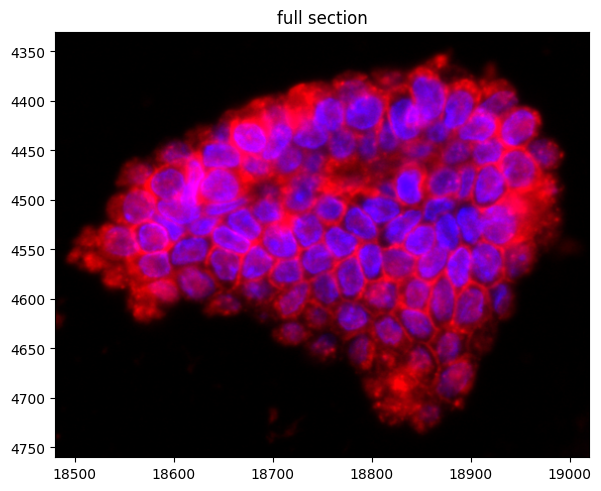

In [2]:
IMG = dict(
    channel=["DAPI", "ATP1A1/CD45/E-Cadherin"],
    palette=["blue", "red"],
    norm=[PercentileNormalize(1, 99)] * 2,
)
sdata.pl.render_images("morphology_focus", **IMG).pl.show(title="full section")

## 1. Zooming in — `crop_coord`

`crop_coord` is a tuple `(xmin, xmax, ymin, ymax)` in the units of the rendered coordinate system —
the same order as `ax.axis(...)` and as `crop_coord` in `scanpy.pl.spatial` /
`squidpy.pl.spatial_scatter`. Here the units are microns; we zoom into a 200 × 200 µm window. The
box and connector lines are plain matplotlib, drawn so you can see where the crop sits.

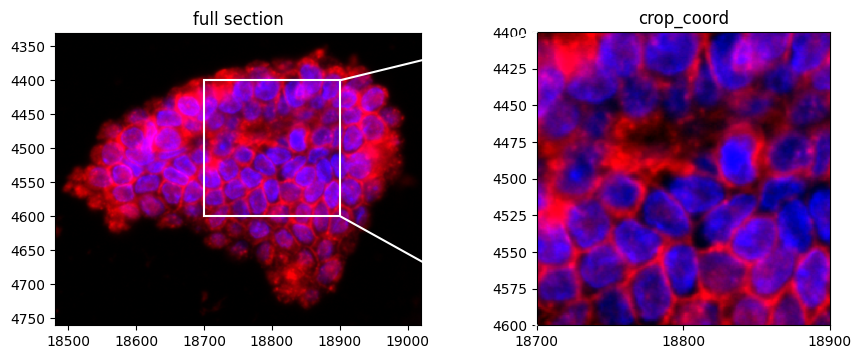

In [3]:
CROP = (18700, 18900, 4400, 4600)  # xmin, xmax, ymin, ymax in µm


def mark_crop(ax_full, ax_crop, crop, **style):
    # draw the crop box on ax_full and connect its right corners to ax_crop
    xmin, xmax, ymin, ymax = crop
    ax_full.add_patch(Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, **style))
    for y, frac in ((ymin, 1), (ymax, 0)):  # y axis is inverted: ymin is the top edge
        ax_full.figure.add_artist(
            ConnectionPatch((xmax, y), (0, frac), coordsA=ax_full.transData, coordsB=ax_crop.transAxes, **style)
        )


fig, (ax_full, ax_crop) = plt.subplots(1, 2, figsize=(10, 4.5), gridspec_kw={"width_ratios": [1.25, 1]})
sdata.pl.render_images("morphology_focus", **IMG).pl.show(ax=ax_full, title="full section")
sdata.pl.render_images("morphology_focus", **IMG).pl.show(ax=ax_crop, crop_coord=CROP, title="crop_coord")
ax_crop.set_xticks([18700, 18800, 18900])
mark_crop(ax_full, ax_crop, CROP, edgecolor="white", color="white", lw=1.5)
fig.subplots_adjust(wspace=0.35)

## 2. One window for every layer

`crop_coord` is a `show()` argument, so it applies to every `render_*` call in the chain. Points and
shapes are subsetted to the window before drawing; images and labels are rasterized for the window only.

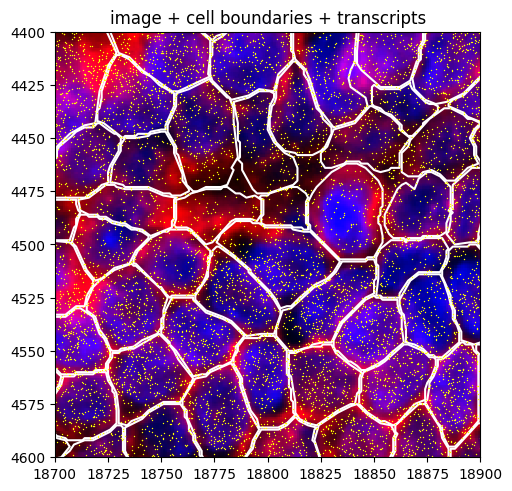

In [4]:
(
    sdata.pl.render_images("morphology_focus", **IMG)
    .pl.render_shapes("cell_boundaries", fill_alpha=0, outline=True, outline_color="white")
    .pl.render_points("transcripts", color="yellow", size=1)
    .pl.show(crop_coord=CROP, title="image + cell boundaries + transcripts")
)

## 3. Keeping colours comparable

Cropping changes what the auto-scaled colour ranges see:

- **Points, shapes and labels** keep the range of the *full* element, so a colour in the crop means
  the same thing as in the uncropped plot — note the identical colorbars below.
- **Images** are contrast-stretched over the *window*, because only the window is ever read. A crop
  of a dim region therefore looks brighter than the same region in the full plot.

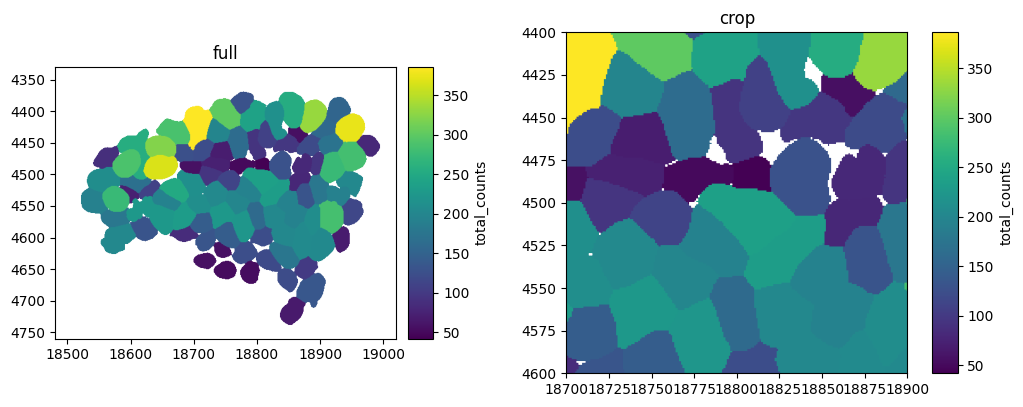

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sdata.pl.render_labels("cell_labels", color="total_counts", fill_alpha=1).pl.show(ax=axes[0], title="full")
sdata.pl.render_labels("cell_labels", color="total_counts", fill_alpha=1).pl.show(
    ax=axes[1], crop_coord=CROP, title="crop"
)
fig.subplots_adjust(wspace=0.5)

The effect is easiest to see on a dim region: the lobe at the bottom right is roughly half as bright
as the brightest nuclei, so cropped on its own it gets stretched to full contrast. To pin image
contrast to the full-image range, pass explicit limits — a `norm` (or `vmin`/`vmax`). Here we take
the 1st and 99th percentile of the full DAPI channel:

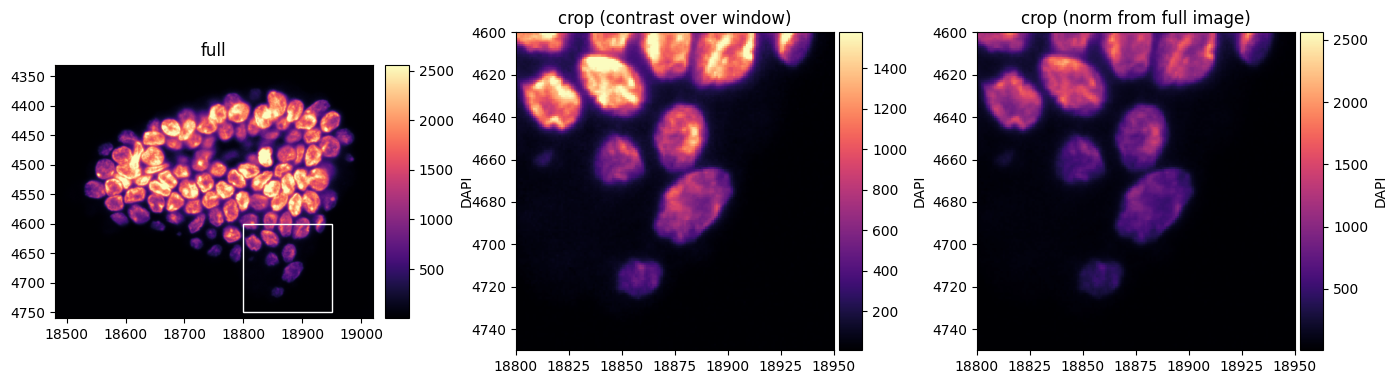

In [6]:
from matplotlib.colors import Normalize

DIM = (18800, 18950, 4600, 4750)  # a dim window at the bottom right

dapi = sdata["morphology_focus"]["scale0"].image.sel(c="DAPI")
fixed = Normalize(*dapi.quantile([0.01, 0.99]).values)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sdata.pl.render_images("morphology_focus", channel="DAPI", cmap="magma", norm=PercentileNormalize(1, 99)).pl.show(
    ax=axes[0], title="full"
)
axes[0].add_patch(Rectangle((DIM[0], DIM[2]), DIM[1] - DIM[0], DIM[3] - DIM[2], fill=False, edgecolor="white"))
sdata.pl.render_images("morphology_focus", channel="DAPI", cmap="magma", norm=PercentileNormalize(1, 99)).pl.show(
    ax=axes[1], crop_coord=DIM, title="crop (contrast over window)"
)
sdata.pl.render_images("morphology_focus", channel="DAPI", cmap="magma", norm=fixed).pl.show(
    ax=axes[2], crop_coord=DIM, title="crop (norm from full image)"
)
fig.subplots_adjust(wspace=0.45)

## 4. `crop_coord` vs `bounding_box_query`

`spatialdata.bounding_box_query` builds a *new* `SpatialData` object containing only the elements
inside the box. `crop_coord` changes only what is drawn. The pictures are the same; the difference is
what you are left with:

- use **`crop_coord`** to *look* at a region — nothing is copied, and images stay lazy;
- use **`bounding_box_query`** when you need the subset as data — to count, analyse, or save it.

Note the axes: `crop_coord` pins the view to the box, whereas the query keeps every cell that
*intersects* the box in full, so its result spills over the edges.

cells: 94 in the full object, 55 in the query result
transcripts: 19479 in the full object, 7466 in the query result


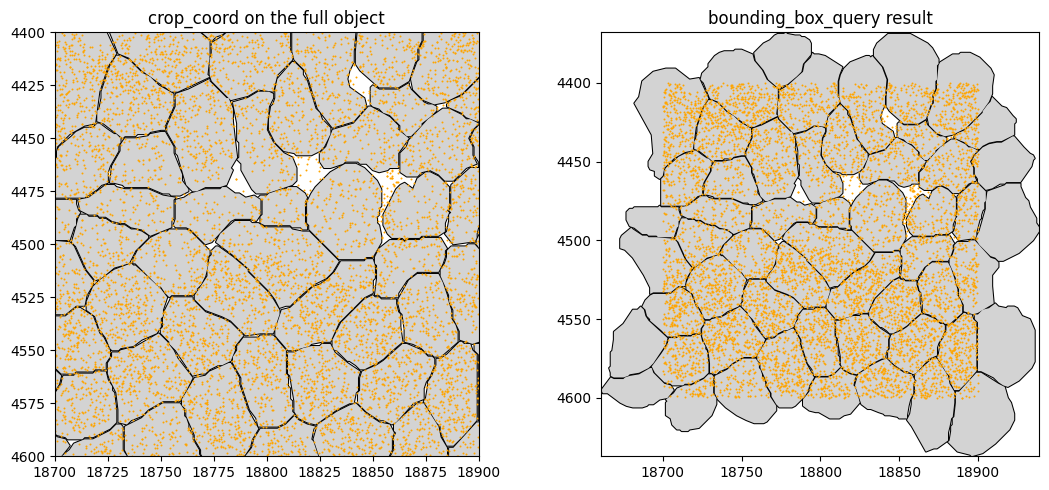

In [7]:
subset = sd.bounding_box_query(
    sdata,
    axes=("x", "y"),
    min_coordinate=[CROP[0], CROP[2]],
    max_coordinate=[CROP[1], CROP[3]],
    target_coordinate_system="global",
)
print(f"cells: {len(sdata['cell_boundaries'])} in the full object, {len(subset['cell_boundaries'])} in the query result")
print(f"transcripts: {len(sdata['transcripts'])} in the full object, {len(subset['transcripts'])} in the query result")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sdata.pl.render_shapes("cell_boundaries", color="lightgray", outline=True).pl.render_points(
    "transcripts", color="orange", size=2
).pl.show(ax=axes[0], crop_coord=CROP, title="crop_coord on the full object")
subset.pl.render_shapes("cell_boundaries", color="lightgray", outline=True).pl.render_points(
    "transcripts", color="orange", size=2
).pl.show(ax=axes[1], title="bounding_box_query result")
fig.tight_layout()

## 5. One coordinate system at a time

The box is expressed in one coordinate system's units, so `crop_coord` requires a single coordinate
system to be rendered. If your object has several, pick one with `coordinate_systems="global"` (or
whichever applies) in the same `show()` call.

## For reproducibility

In [8]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,squidpy,matplotlib,numpy

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_plot: 0.4.2
squidpy         : 1.8.3
matplotlib      : 3.10.9
numpy           : 2.4.4

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

